# Session 3 — Pixel Losses and Honest Scores 🧪

**Time:** 35–40 minutes  
**Goal:** score a segmentation prediction while excluding ignored border pixels.

You will work with tiny masks where every count is visible, then use the same accumulation pattern used for a validation set.

## 0. Setup

This lab has no download and no training step. Run the cells in order.

In [ ]:
import torch
import torch.nn.functional as F

torch.manual_seed(7)
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
print('PyTorch:', torch.__version__)

PyTorch: 2.11.0+cpu


## 1. From logits to a mask (5 min)

A model gives two **logits** per pixel: one for background and one for pet. Softmax turns each pair into probabilities that sum to one; `argmax` selects the larger probability.

In [ ]:
# Shape: [batch, classes, height, width]
logits = torch.tensor([[[[3.0, -1.0], [0.2, 1.2]],
                        [[-1.0, 3.0], [1.5, 0.3]]]])
probabilities = logits.softmax(dim=1)
prediction = probabilities.argmax(dim=1)

print('logits shape:       ', tuple(logits.shape))
print('probability sums:\n', probabilities.sum(dim=1))
print('prediction shape:   ', tuple(prediction.shape))
print('predicted labels:\n', prediction[0])
assert torch.allclose(probabilities.sum(dim=1), torch.ones_like(probabilities[:, 0]))
assert prediction.shape == (1, 2, 2)

logits shape:        (1, 2, 2, 2)
probability sums:
 tensor([[[1., 1.],
         [1., 1.]]])
prediction shape:    (1, 2, 2)
predicted labels:
 tensor([[0, 1],
        [1, 0]])


## 2. Ignored borders do not vote (6 min)

Oxford-IIIT Pet trimaps use `255` for an ambiguous border. It is neither background nor pet, so it must be excluded from both the loss and every metric.

In [ ]:
targets = torch.tensor([[[0, 1], [IGNORE_INDEX, 0]]])
valid = targets != IGNORE_INDEX
loss = F.cross_entropy(logits, targets, ignore_index=IGNORE_INDEX)

print('valid pixels:', int(valid.sum()), 'of', targets.numel())
print('valid mask:\n', valid[0])
print(f'cross-entropy on valid pixels only: {loss.item():.3f}')
assert int(valid.sum()) == 3

valid pixels: 3 of 4
valid mask:
 tensor([[ True,  True],
        [False,  True]])
cross-entropy on valid pixels only: 0.126


## 3. Exercise E1 — accumulate only valid pixels (10 min)

Complete the helper below. It must update a 2×2 confusion matrix whose **rows are true classes** and **columns are predicted classes**. Ignore every target equal to `255`.

In [ ]:
# TODO: update the confusion matrix using only target != IGNORE_INDEX pixels
def update_confusion(confusion, target, predicted):
    """Add one image's valid-pixel votes to a running [true, predicted] confusion matrix."""
    valid = target != IGNORE_INDEX
    true_valid = target[valid].to(torch.int64)
    pred_valid = predicted[valid].to(torch.int64)
    num_classes = confusion.shape[0]
    flat_indices = true_valid * num_classes + pred_valid
    counts = torch.bincount(flat_indices, minlength=num_classes * num_classes)
    confusion += counts.reshape(num_classes, num_classes)
    return confusion

def scores_from_confusion(confusion):
    """Pixel accuracy and per-class IoU computed from accumulated confusion counts."""
    confusion = confusion.to(torch.float64)
    true_positive = torch.diag(confusion)
    total = confusion.sum()
    accuracy = (true_positive.sum() / total).item() if total > 0 else float('nan')
    union = confusion.sum(dim=1) + confusion.sum(dim=0) - true_positive
    class_iou = torch.where(union > 0, true_positive / union, torch.zeros_like(union))
    return accuracy, class_iou


In [ ]:
# Two small saved predictions: accumulate counts first, then score once.
batch_targets = [
    torch.tensor([[0, 1], [1, IGNORE_INDEX]]),
    torch.tensor([[0, 0], [1, 1]]),
]
batch_predictions = [
    torch.tensor([[0, 1], [0, 1]]),
    torch.tensor([[0, 1], [1, 0]]),
]

confusion = torch.zeros((2, 2), dtype=torch.int64)
for target, predicted in zip(batch_targets, batch_predictions):
    confusion = update_confusion(confusion, target, predicted)

accuracy, class_iou = scores_from_confusion(confusion)
print('rows=true, columns=predicted')
print(confusion)
print(f'dataset pixel accuracy: {accuracy:.3f}')
print(f'background IoU: {class_iou[0]:.3f}; pet IoU: {class_iou[1]:.3f}')
assert confusion.sum().item() == 7  # one of eight cells was ignored
assert torch.all((class_iou >= 0) & (class_iou <= 1))

rows=true, columns=predicted
tensor([[2, 1],
        [2, 2]])
dataset pixel accuracy: 0.571
background IoU: 0.400; pet IoU: 0.400


**Why accumulate?** Averaging IoU separately for each image gives every image equal weight, even if one has many more valid pixels. A validation report should state its aggregation rule; here we total counts over the dataset before calculating the score.

## 4. Exercise E2 — the worked 4×4 pet IoU (8 min)

For the pet class, find `TP`, `FP`, and `FN`. The ignored lower-right cell must disappear before counting. The expected result is $3/(3+1+1)=0.60$.

In [ ]:
target_4x4 = torch.tensor([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, IGNORE_INDEX],
])
predicted_4x4 = torch.tensor([
    [1, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 1],
])

In [ ]:
# TODO: calculate the pet TP, FP, FN, and IoU while excluding ignored labels
valid = target_4x4 != IGNORE_INDEX
truth_pet = (target_4x4 == 1) & valid
predicted_pet = (predicted_4x4 == 1) & valid

true_positive = (truth_pet & predicted_pet).sum().item()
false_positive = (~truth_pet & predicted_pet).sum().item()
false_negative = (truth_pet & ~predicted_pet).sum().item()
pet_iou = true_positive / (true_positive + false_positive + false_negative)

print(f'TP={true_positive}, FP={false_positive}, FN={false_negative}')
print(f'pet IoU: {pet_iou:.2f}')
assert (true_positive, false_positive, false_negative) == (3, 1, 1)
assert abs(pet_iou - 0.60) < 1e-9

TP=3, FP=1, FN=1
pet IoU: 0.60


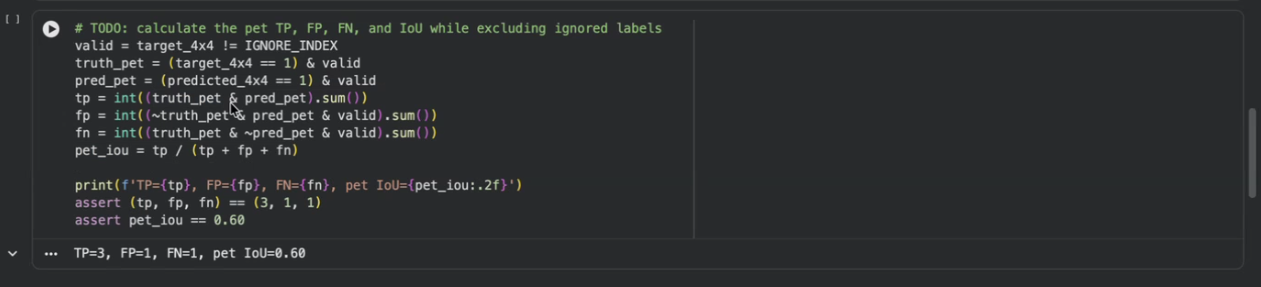

## 5. Accuracy can hide a bad foreground mask (5 min)

Suppose a 10×10 image contains only four pet pixels. A model predicts every pixel as background. It is correct on 96 of 100 pixels, but it finds none of the pet.

In [ ]:
rare_target = torch.zeros((10, 10), dtype=torch.int64)
rare_target[:2, :2] = 1
all_background = torch.zeros_like(rare_target)

rare_confusion = torch.zeros((2, 2), dtype=torch.int64)
rare_confusion = update_confusion(rare_confusion, rare_target, all_background)
rare_accuracy, rare_iou = scores_from_confusion(rare_confusion)
print(f'pixel accuracy: {rare_accuracy:.2%}')
print(f'pet IoU: {rare_iou[1]:.2f}')
assert rare_accuracy == 0.96 and rare_iou[1] == 0.0

pixel accuracy: 96.00%
pet IoU: 0.00


> TODO: In one or two sentences, explain why the 96% pixel accuracy above is misleading.


*   Respuesta: La precisión por pixel está dominada por la clase mayoritaria; en este caso, el fondo cubre 96 de 100 pixeles, por lo que un modelo que nunca predice la mascota aún obtiene un 96% simplemente copiando el fondo. El IoU de la mascota de 0.0 revela lo que la precisión oculta, el modelo no encuentra nada del objeto en primer plano, que es precisamente lo que suele ser el foco de interés.




## Checkpoint

Before leaving, confirm that you can explain: (1) why `255` is excluded, (2) why the 4×4 pet IoU is 0.60, and (3) why a dataset metric starts from accumulated counts. Next session you will use these metrics to evaluate a pretrained segmentation model.